Valeurs manquantes après imputation: 0

=== Performance du modèle ===
              precision    recall  f1-score   support

         0.0       0.85      0.62      0.72       186
         1.0       0.63      0.85      0.73       141

    accuracy                           0.72       327
   macro avg       0.74      0.74      0.72       327
weighted avg       0.75      0.72      0.72       327

Accuracy: 0.7217


c:\Users\Amatek\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


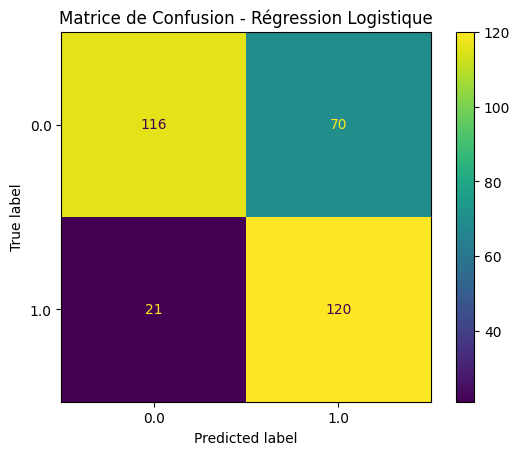

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv('missions_fusionnees.csv')

time_cols = [col for col in df.columns if col.startswith('time_')]
features = df.drop(['mission_id', 'is_attack'] + time_cols, axis=1, errors='ignore')

features = features.apply(pd.to_numeric, errors='coerce')
imputer = SimpleImputer(strategy='mean')  # Alternative: 'median' ou 'most_frequent'
features_imputed = imputer.fit_transform(features)

print("Valeurs manquantes après imputation:", np.isnan(features_imputed).sum())

X_train, X_test, y_train, y_test = train_test_split(
    features_imputed, 
    df['is_attack'], 
    test_size=0.3, 
    random_state=42,
    stratify=df['is_attack']
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

try:
    lr = LogisticRegression(
        max_iter=1,
        random_state=42,
        class_weight='balanced'
    )
    lr.fit(X_train_scaled, y_train)
   
    y_pred = lr.predict(X_test_scaled)
    
    print("\n=== Performance du modèle ===")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
    disp.plot()
    plt.title("Matrice de Confusion - Régression Logistique")
    plt.show()

except Exception as e:
    print(f"Erreur lors de l'entraînement: {str(e)}")
    print("\nVérifiez que:")
    print("1. Toutes les colonnes sont numériques")
    print("2. Il n'y a pas de valeurs NaN dans les données")
    print("3. La target ne contient que 0 et 1")

In [3]:
import joblib

joblib.dump(lr, "LR_21.pkl")

['LR_21.pkl']